<a href="https://colab.research.google.com/github/arunpradeep-g/Python-Programs/blob/main/04_boston_housing_price_predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Regression Example With Boston Dataset: Baseline
import numpy
import scikeras
from pandas import read_csv
from keras.models import Sequential
#from keras.layers import Dense
#from keras.wrappers.scikit_learn import KerasRegressor
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from tensorflow.keras.layers import Dense, Input


In [3]:
# load dataset
dataframe = read_csv("https://raw.githubusercontent.com/arunpradeep-g/Python-Programs/refs/heads/main/housing.csv",sep=r"\s+", header=None)
dataset = dataframe.values
# split into input (X) and output (Y) variables
X = dataset[:,0:13]
Y = dataset[:,13]

In [4]:
from scikeras.wrappers import KerasRegressor
# fix random seed for reproducibility
seed = 7
numpy.random.seed(seed)

In [5]:
# Model builder
def build_model():
    model = Sequential([
        Input(shape=(13,)),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# evaluate model
estimator = KerasRegressor(model=build_model, epochs=100, batch_size=5, verbose=0)

# build model
model = build_model()

model.fit(X, Y, epochs=100, batch_size=32)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 295.8792    
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 92.0241 
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 72.4841  
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 63.8386 
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 61.0902 
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 57.3709 
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 57.4114 
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 53.3167 
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 54.6919 
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 51.0120 
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 49.6640 
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 48.7610 
Epoch 13/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 47.2573 
Epoch 14/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 48.3987 
Epoch 15/100
16/16 ━━━━━━━━━━━━━━━━━━━

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

kfold = KFold(n_splits=10, random_state=seed, shuffle=True)
results = cross_val_score(estimator, X, Y, cv=kfold)
print("Baseline: %.2f (%.2f) MSE" % (results.mean(), results.std()))

# Choose feature indices
RM_idx = 5      # RM column
LSTAT_idx = 12  # LSTAT column

Baseline: 0.64 (0.09) MSE


79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


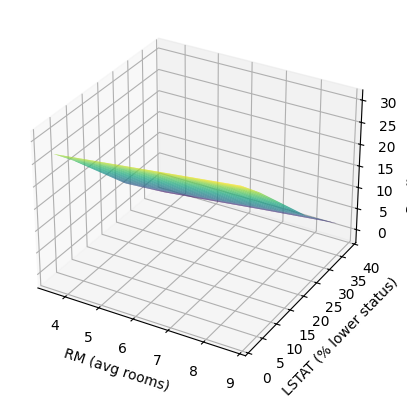

In [7]:
# Create grid for RM and LSTAT
rm_range = np.linspace(X[:, RM_idx].min(), X[:, RM_idx].max(), 50)
lstat_range = np.linspace(X[:, LSTAT_idx].min(), X[:, LSTAT_idx].max(), 50)

rm_grid, lstat_grid = np.meshgrid(rm_range, lstat_range)

# Create full input (keep other features constant = mean)
X_surface = np.tile(np.mean(X, axis=0), (rm_grid.size, 1))

X_surface[:, RM_idx] = rm_grid.ravel()
X_surface[:, LSTAT_idx] = lstat_grid.ravel()

# Predict
Z = model.predict(X_surface)
Z = Z.reshape(rm_grid.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(rm_grid, lstat_grid, Z, cmap='viridis')

ax.set_xlabel("RM (avg rooms)")
ax.set_ylabel("LSTAT (% lower status)")
ax.set_zlabel("Predicted Price")

plt.show()